# Portfolio Data Collections

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [270]:
import pandas as pd

# Create the portfolio data
trump_tickers = {
    'Ticker': ['NVDA', 'TSLA', 'AAPL', 'BA', 'XOM', 'PLTR', 'JPM', 'DELL', 
               'BLK', 'GS', 'INTC', 'MU', 'MA', 'V', 'QCOM'],
    'Company': ['NVIDIA', 'Tesla', 'Apple', 'Boeing', 'ExxonMobil', 'Palantir', 
                'JPMorgan Chase & Co.', 'Dell Technologies', 'BlackRock', 
                'Goldman Sachs', 'Intel', 'Micron', 'Mastercard', 'Visa', 'Qualcomm'],
    'Weight': [10.0, 9.0, 8.5, 7.5, 7.0, 6.5, 6.0, 6, 7.0, 7.5, 7.5, 4.5, 4.5, 4.5, 4.0]
}

# Create DataFrame
ticker_data = pd.DataFrame(trump_tickers)
ticker_data = ticker_data.sort_values('Ticker', ascending=True)
ticker_data.to_csv('/Users/My World/Passion/VeroQuant/Portfolios/PortfolioRiskAnalytics/data/trump_tickers.csv', index = False)


In [271]:
def portfolio_analytics(tickers, risk_free_rate, start_date, n_trading_days, confidence_level,weights = None, port_type = None):
    import yfinance as yf
    import pandas as pd
    import numpy as np
    rng = np.random.default_rng(1000)
    
    # Loading the data 
    df_close = yf.download(tickers=tickers, start=start_date, auto_adjust=True)['Close']
    df_close.columns = tickers
    df_vol = yf.download(tickers=tickers, start=start_date, auto_adjust=True)['Volume']
    df_vol.columns = tickers
    
    # Market Cap data
    market_caps = []

    for ticker in tickers:
        t = yf.Ticker(ticker)
        market_caps.append(t.info['marketCap'])

    # Wrangling the data
    drop_10na_cols = df_close.columns[df_close.isna().sum() > 200]
    df_close = df_close.drop(columns=drop_10na_cols)
    df_mcap = df_close * df_vol
    
    if len(drop_10na_cols) == 0:
        print(f'... Less than 10% NA Values!')
    else:
        print(f' More than 10% NA in the columns: {drop_10na_cols}')

    # Log returns
    df_returns = np.log(df_close / df_close.shift(1)).dropna()
    n_assets = df_returns.shape[1]
    
    # Weighting techniques (EW = Equal Weighted, MC = Market Cap, RP = Risk Parity, CW = Customized, Else --> random weights)
    if port_type == 'EW':
        weights = np.ones(n_assets) / n_assets
    
    elif port_type == 'MC':
        weights = np.array(market_caps)
        weights = weights / weights.sum()
        # weights = df_mcap.iloc[-1].values (proxy for MCap)
        # weights = weights / weights.sum()

    elif port_type == 'RP':
        weights = 1 / df_returns.std().values
        weights /= weights.sum()
    
    elif port_type == 'CW':
    
        if weights is None:
            raise ValueError("For port_type='CW', you must provide weights parameter")
    
        weights = np.array(weights).flatten()
        weights = weights / weights.sum()

    else:
        weights = rng.random(size=n_assets)
        weights /= weights.sum()


    # Portfolio Returns
    cov_mat = df_returns.cov()
    corr_mat = df_returns.corr()
    port_returns =  df_returns @ weights
    port_variance = weights.T @ cov_mat @ weights

    # Annualized Returns
    annual_returns = port_returns.mean() * n_trading_days
    annual_std = np.sqrt(port_variance * n_trading_days)
    annual_sharpe = (annual_returns - risk_free_rate) / annual_std

    # Calculating VaR and ES (annualized assuming IID and Gaussian)
    daily_var = np.percentile(port_returns, (1 - confidence_level) * 100) # remember: np.quantile(df_returns, 1 - confidence_level) as it takes 0.95 format.
    annual_var = daily_var * np.sqrt(n_trading_days)
    daily_es = port_returns[port_returns <= daily_var].mean()
    annual_es = daily_es * np.sqrt(n_trading_days)

    annual_results = pd.DataFrame({
        'Annual Port Return': [annual_returns],
        'Annual Port Std': [annual_std],
        'Annual Port Sharpe': [annual_sharpe],
        f'Annual VaR_{confidence_level}': [annual_var],
        f'Annual ES_{confidence_level}': [annual_es]
    })

    # Risk Attribution
    overall_port_std = np.sqrt(weights.T @ cov_mat @ weights)
    marginal_risk_contribution = (cov_mat @ weights) / overall_port_std
    component_risk_contribution = weights * marginal_risk_contribution
    pct_risk_contribution = component_risk_contribution / component_risk_contribution.sum()
    
    risk_attribution = pd.DataFrame({
        'Asset': df_returns.columns,
        'Weight': weights,
        'Marginal Risk Contribution': marginal_risk_contribution,
        'Component Risk Contribution': component_risk_contribution,
        '% of Total Risk': pct_risk_contribution
    })


    return annual_results, risk_attribution, corr_mat, port_returns, daily_var, daily_es



[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  5 of 5 completed


... Less than 10% NA Values!
Result
   Annual Port Return  Annual Port Std  Annual Port Sharpe  Annual VaR_0.999  \
0            0.231004         0.261983            0.805411         -1.184693   

   Annual ES_0.999  
0        -1.577138  


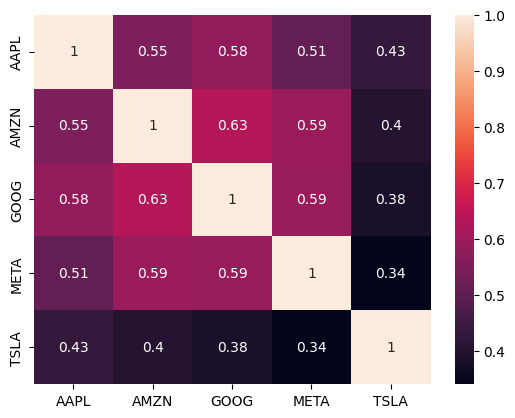

In [272]:
# Toy Examples
risk_free_rate = 0.02
n_trading_days = 252
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'TSLA']
weights = [.20, .30, .80, .9, .9]
port_type = ['EW', 'MC', 'RP', 'OO']
confidence_level = 0.999

annual_results , risk_breakdown, corr_mat, port_returns, daily_var, daily_es = portfolio_analytics(
    tickers=tickers, 
    risk_free_rate=risk_free_rate, 
    start_date= '2015-01-01',
    n_trading_days=n_trading_days, 
    confidence_level=confidence_level, 
    weights=weights, 
    port_type='MC')

print('Result')
print(annual_results)
risk_breakdown.sort_values('% of Total Risk', ascending=False) 

import seaborn as sns
sns.heatmap(corr_mat, annot=True)
plt.show()

In [273]:
# Trump Portfolio Analysis 
results, risk_breakdown, corr_mat, port_returns, daily_var, daily_es = portfolio_analytics(
    tickers=ticker_data['Ticker'].to_list(), 
    risk_free_rate=0.02,
    start_date= '2017-01-19',
    weights=ticker_data['Weight'].to_list(),
    confidence_level=0.999,
    port_type='RP', 
    n_trading_days=252)

print('Results')
print(results)
risk_breakdown.sort_values('% of Total Risk', ascending=False)

[*********************100%***********************]  15 of 15 completed
[*********************100%***********************]  15 of 15 completed


 More than 10% NA in the columns: Index(['PLTR'], dtype='object')
Results
   Annual Port Return  Annual Port Std  Annual Port Sharpe  Annual VaR_0.999  \
0            0.201047         0.240938            0.751428         -1.522656   

   Annual ES_0.999  
0        -1.989385  


,Asset,Weight,Marginal Risk Contribution,Component Risk Contribution,% of Total Risk
BLK,BLK,0.088708,0.014009,0.001243,0.081881
GS,GS,0.082880,0.014805,0.001227,0.080843
MA,MA,0.091282,0.013305,0.001215,0.080019
V,V,0.100679,0.011983,0.001206,0.079488
JPM,JPM,0.090045,0.013100,0.001180,0.077719
AAPL,AAPL,0.084917,0.013568,0.001152,0.075912
QCOM,QCOM,0.062969,0.017339,0.001092,0.071936
NVDA,NVDA,0.050287,0.021709,0.001092,0.071927
MU,MU,0.049678,0.021755,0.001081,0.071206
BA,BA,0.058448,0.017900,0.001046,0.068932


[*********************100%***********************]  1 of 1 completed


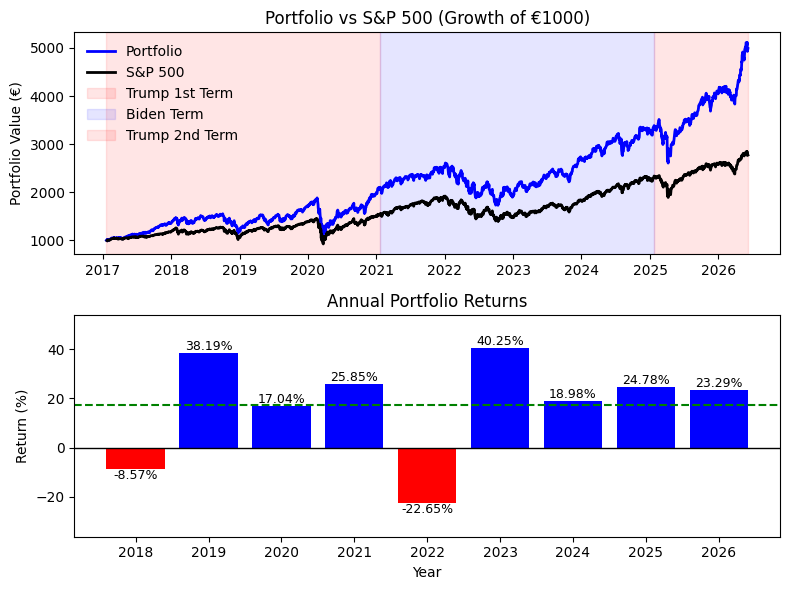

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [277]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_benchmark(port_returns, initial_investment=1000, benchmark_ticker="^GSPC"):

    # =========================
    # PORTFOLIO VALUE
    # =========================
    portfolio_value = initial_investment * (1 + port_returns).cumprod()
    portfolio_value.index = pd.to_datetime(portfolio_value.index)

    # =========================
    # BENCHMARK
    # =========================
    sp500 = yf.download(
        benchmark_ticker,
        start=portfolio_value.index.min(),
        auto_adjust=True
    )["Close"]

    sp500_returns = np.log(sp500 / sp500.shift(1)).dropna()

    benchmark_value = initial_investment * (1 + sp500_returns).cumprod()
    benchmark_value = benchmark_value.reindex(portfolio_value.index).ffill()

    # =========================
    # ANNUAL RETURNS
    # =========================
    annual_port = portfolio_value.resample("YE").last().pct_change().dropna()

    # =========================
    # FIGURE (2 SUBPLOTS)
    # =========================
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))

    # =========================
    # 1. GROWTH CURVE
    # =========================
    axes[0].plot(portfolio_value, label="Portfolio", color="blue", linewidth=2)
    axes[0].plot(benchmark_value, label="S&P 500", color="black", linewidth=2)

    axes[0].set_title("Portfolio vs S&P 500 (Growth of €1000)")
    axes[0].set_ylabel("Portfolio Value (€)")
    axes[0].grid(False)
    axes[0].legend()


    # Define presidential terms
    presidential_terms = {
        'Trump 1st Term': ('2017-01-20', '2021-01-20'),
        'Biden Term': ('2021-01-20', '2025-01-20'),
        'Trump 2nd Term': ('2025-01-20', '2029-01-20'),
    }

    colors = {'Trump 1st Term': 'red', 'Biden Term': 'blue', 'Trump 2nd Term': 'red'}

    for term_name, (start, end) in presidential_terms.items():
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        
        # Check if data overlaps with term
        if start_date <= portfolio_value.index.max() and end_date >= portfolio_value.index.min():
            shade_start = max(start_date, portfolio_value.index.min())
            shade_end = min(end_date, portfolio_value.index.max())
            
            axes[0].axvspan(shade_start, shade_end, alpha=0.10, color=colors[term_name], label=term_name)

    axes[0].legend(loc = 'best', frameon = False)


    # =========================
    # 2. ANNUAL RETURNS BAR CHART
    # =========================
    # Create the bar chart
    bars = axes[1].bar(
        annual_port.index.year.astype(str),
        annual_port.values * 100,
        color=np.where(annual_port.values > 0, "blue", "red")
    )

    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].axhline(annual_port.values.mean() * 100, color="green", linestyle = '--', linewidth=1.5)
    axes[1].set_title("Annual Portfolio Returns")
    axes[1].set_ylabel("Return (%)")
    axes[1].set_xlabel("Year")
    axes[1].grid(False, axis="y")

    # Add labels with automatic y-limit adjustment
    for bar in bars:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.2f}%',
            ha='center',
            va='bottom' if height >= 0 else 'top',
            fontsize=9
        )

    current_bottom, current_top = axes[1].get_ylim()
    padding = 0.15
    new_top = current_top + (current_top - current_bottom) * padding
    new_bottom = current_bottom - (current_top - current_bottom) * padding

    axes[1].set_ylim(bottom=new_bottom, top=new_top)
    plt.tight_layout()
    plt.show()

    return portfolio_value, benchmark_value


add_benchmark(port_returns=port_returns, initial_investment=1000, benchmark_ticker='^GSPC')
plt.tight_layout()
plt.show()

plt.savefig(
    "/Users/My World/Passion/VeroQuant/Portfolios/PortfolioRiskAnalytics/results/portfolio_vs_sp500.png",
    dpi=300,
    bbox_inches="tight"
)